In [1]:
#Imported libraries

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib 
matplotlib.rcParams["figure.figsize"] = (20,10)

In [2]:
# Loaded dataset

df1 = pd.read_csv("../Data/raw/bengaluru_house_prices.csv")
df1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
#Checked shape

df1.shape

(13320, 9)

In [4]:
# Checked column info

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [5]:
#Checked missing values for each col

df1.isnull().sum()
# size has only 16 missing values, so we can drop those rows.
# same w location

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [6]:
#Checked unique values

df1.nunique()

area_type          4
availability      81
location        1305
size              31
society         2688
total_sqft      2117
bath              19
balcony            4
price           1994
dtype: int64

In [7]:
# Checked area type

df1['area_type'].value_counts()

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64

In [8]:
# Checked statistical summary

df1.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [9]:
#Checked top locations
df1["location"].value_counts().head(20)

location
Whitefield                  540
Sarjapur  Road              399
Electronic City             302
Kanakpura Road              273
Thanisandra                 234
Yelahanka                   213
Uttarahalli                 186
Hebbal                      177
Marathahalli                175
Raja Rajeshwari Nagar       171
Bannerghatta Road           152
Hennur Road                 152
7th Phase JP Nagar          149
Haralur Road                142
Electronic City Phase II    132
Rajaji Nagar                107
Chandapura                  100
Bellandur                    96
KR Puram                     91
Electronics City Phase 1     88
Name: count, dtype: int64

In [10]:
#checked size values
df1["size"].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', nan, '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [11]:
#Checked total_sqft values
df1["total_sqft"].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

### cleaning

In [12]:
#Checked missing size rows
df1[df1["size"].isnull()]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
579,Plot Area,Immediate Possession,Sarjapur Road,NaN,Asiss B,1200 - 2400,NaN,NaN,34.185
1775,Plot Area,Immediate Possession,IVC Road,NaN,Orana N,2000 - 5634,NaN,NaN,124.000
2264,Plot Area,Immediate Possession,Banashankari,NaN,NaN,2400,NaN,NaN,460.000
2809,Plot Area,Immediate Possession,Sarjapur Road,NaN,AsdiaAr,1200 - 2400,NaN,NaN,28.785
2862,Plot Area,Immediate Possession,Devanahalli,NaN,Ajleyor,1500 - 2400,NaN,NaN,46.800
5333,Plot Area,Immediate Possession,Devanahalli,NaN,Emngs S,2100 - 5405,NaN,NaN,177.115
6423,Plot Area,Immediate Possession,Whitefield,NaN,SRniaGa,2324,NaN,NaN,26.730
6636,Plot Area,Immediate Possession,Jigani,NaN,S2enste,1500,NaN,NaN,25.490
6719,Plot Area,Immediate Possession,Hoskote,NaN,SJowsn,800 - 2660,NaN,NaN,28.545
7680,Plot Area,Immediate Possession,Kasavanhalli,NaN,NaN,5000,NaN,NaN,400.000


Since only 16 rows have missing size, we can safely drop them for now:

In [13]:
df2 = df1.dropna(subset=["size"]).copy()
#df2 = df1 but without rows where size is missing. => -165 rows

In [14]:
df2["bhk"] = df2["size"].apply(lambda x: int(x.split(" ")[0]))
#Created bhk column
#size = original text column
#bhk = useful numeric column

In [15]:
df2[["size", "bhk"]].head(10)

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2
5,2 BHK,2
6,4 BHK,4
7,4 BHK,4
8,3 BHK,3
9,6 Bedroom,6


In [16]:
#Checked bhk values
df2["bhk"].unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [17]:
df2["total_sqft"].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [18]:
#To check whether total_sqft can directly become a number.
def is_float(x):
    try:
        float(x)
        return True
    except:
        return False


In [19]:
#Displayed non-float total_sqft rows
df2[~df2["total_sqft"].apply(is_float)].head(20) #return where total_sqft is not a float value

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk
30,Super built-up Area,19-Dec,Yelahanka,4 BHK,LedorSa,2100 - 2850,4.0,0.0,186.000,4
56,Built-up Area,20-Feb,Devanahalli,4 Bedroom,BrereAt,3010 - 3410,NaN,NaN,192.000,4
81,Built-up Area,18-Oct,Hennur Road,4 Bedroom,Gollela,2957 - 3450,NaN,NaN,224.500,4
122,Super built-up Area,18-Mar,Hebbal,4 BHK,SNontle,3067 - 8156,4.0,0.0,477.000,4
137,Super built-up Area,19-Mar,8th Phase JP Nagar,2 BHK,Vaarech,1042 - 1105,2.0,0.0,54.005,2
165,Super built-up Area,18-Dec,Sarjapur,2 BHK,Kinuerg,1145 - 1340,2.0,0.0,43.490,2
188,Super built-up Area,Ready To Move,KR Puram,2 BHK,MCvarar,1015 - 1540,2.0,0.0,56.800,2
224,Super built-up Area,19-Dec,Devanahalli,3 BHK,Jurdsig,1520 - 1740,NaN,NaN,74.820,3
410,Super built-up Area,Ready To Move,Kengeri,1 BHK,NaN,34.46Sq. Meter,1.0,0.0,18.500,1
549,Super built-up Area,18-Sep,Hennur Road,2 BHK,Shxorm,1195 - 1440,2.0,0.0,63.770,2


In [20]:
# Listed all weird total_sqft values (which are not float)
df2[~df2["total_sqft"].apply(is_float)]["total_sqft"].unique()

array(['2100 - 2850', '3010 - 3410', '2957 - 3450', '3067 - 8156',
       '1042 - 1105', '1145 - 1340', '1015 - 1540', '1520 - 1740',
       '34.46Sq. Meter', '1195 - 1440', '4125Perch', '1120 - 1145',
       '4400 - 6640', '3090 - 5002', '4400 - 6800', '1160 - 1195',
       '1000Sq. Meter', '4000 - 5249', '1115 - 1130', '1100Sq. Yards',
       '520 - 645', '1000 - 1285', '3606 - 5091', '650 - 665',
       '633 - 666', '5.31Acres', '30Acres', '1445 - 1455', '884 - 1116',
       '850 - 1093', '1440 - 1884', '716Sq. Meter', '547.34 - 827.31',
       '580 - 650', '3425 - 3435', '1804 - 2273', '3630 - 3800',
       '660 - 670', '1500Sq. Meter', '620 - 933', '142.61Sq. Meter',
       '2695 - 2940', '1574Sq. Yards', '3450 - 3472', '1250 - 1305',
       '670 - 980', '1005.03 - 1252.49', '1004 - 1204', '361.33Sq. Yards',
       '645 - 936', '2710 - 3360', '2249.81 - 4112.19', '3436 - 3643',
       '2830 - 2882', '596 - 804', '1255 - 1863', '1300 - 1405',
       '117Sq. Yards', '934 - 1437', '9

In [21]:
unit_conversion = {
    "Sq. Meter": 10.7639,
    "Sq. Yards": 9.0,
    "Acres": 43560,
    "Guntha": 1089,
    "Grounds": 2400,
    "Cents": 435.6,
    "Perch": 272.25
}

In [22]:
def convert_sqft_to_num(x):

    # range case
    if "-" in x:
        tokens = x.split("-")
        return (float(tokens[0]) + float(tokens[1])) / 2

    # normal float
    try:
        return float(x)
    except:
        pass

    # unit conversion
    for unit, factor in unit_conversion.items():

        if unit in x:

            value = float(x.replace(unit, ""))
            return value * factor

    return None

In [23]:
convert_sqft_to_num("34.46Sq. Meter") #testinggg

370.923994

In [24]:
convert_sqft_to_num("1100Sq. Yards") #test2

9900.0

In [25]:
convert_sqft_to_num("5.31Acres") #test3

231303.59999999998

### df1 = raw data
### df2 = size cleaned + bhk added
### df3 = total_sqft cleaned

In [26]:
df3 = df2.copy()

df3["total_sqft"] = df3["total_sqft"].apply(convert_sqft_to_num)

In [27]:
df3["total_sqft"].isnull().sum()

0

***

In [28]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13304 entries, 0 to 13319
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13304 non-null  object 
 1   availability  13304 non-null  object 
 2   location      13303 non-null  object 
 3   size          13304 non-null  object 
 4   society       7805 non-null   object 
 5   total_sqft    13304 non-null  float64
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13304 non-null  float64
 9   bhk           13304 non-null  int64  
dtypes: float64(4), int64(1), object(5)
memory usage: 1.1+ MB


In [29]:
df3[["price", "total_sqft"]].head(10)

,price,total_sqft
0,39.07,1056.0
1,120.00,2600.0
2,62.00,1440.0
3,95.00,1521.0
4,51.00,1200.0
5,38.00,1170.0
6,204.00,2732.0
7,600.00,3300.0
8,63.25,1310.0
9,370.00,1020.0


In [30]:
df4 = df3.copy()

df4["price_per_sqft"] = (df4["price"] * 100000) / df4["total_sqft"]

In [31]:
df4

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440.0,2.0,3.0,62.00,3,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,3,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200.0,2.0,1.0,51.00,2,4250.000000
...,...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453.0,4.0,0.0,231.00,5,6689.834926
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600.0,5.0,NaN,400.00,4,11111.111111
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141.0,2.0,1.0,60.00,2,5258.545136
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689.0,4.0,1.0,488.00,4,10407.336319


In [32]:
df4["price_per_sqft"].describe()

count    1.330400e+04
mean     7.907208e+03
std      1.063129e+05
min      2.257423e+00
25%      4.263721e+03
50%      5.433101e+03
75%      7.313431e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

***
#price_per_sqft = ₹1.2 crore per sqft (max)-impossible

Typical:
₹4000 - ₹10000 per sqft

Luxury:
₹15000 - ₹30000 per sqft

max:
₹12000000 per sqft
***

In [33]:
df4[df4["price_per_sqft"] == df4["price_per_sqft"].max()]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft
4086,Plot Area,Ready To Move,Sarjapur Road,4 Bedroom,NaN,1.0,4.0,NaN,120.0,4,12000000.0


In [34]:
#absurd

In [35]:
df4["sqft_per_bhk"] = df4["total_sqft"] / df4["bhk"]

In [36]:
df4[["total_sqft","bhk","sqft_per_bhk"]].head()

,total_sqft,bhk,sqft_per_bhk
0,1056.0,2,528.0
1,2600.0,4,650.0
2,1440.0,3,480.0
3,1521.0,3,507.0
4,1200.0,2,600.0


In [37]:
df4["sqft_per_bhk"].describe()

count     13304.000000
mean        701.787323
std        6563.099419
min           0.250000
25%         473.333333
50%         552.500000
75%         625.000000
max      653400.000000
Name: sqft_per_bhk, dtype: float64

In [38]:
# If a house has less than 300 sqft per bedroom, it’s likely bad data.

In [39]:
df4[df4["sqft_per_bhk"] < 300].shape  #This tells us how many suspicious houses exist.

(748, 12)

In [40]:
df4[df4["sqft_per_bhk"] < 300].head(20)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020.0,6.0,NaN,370.0,6,36274.509804,170.000000
45,Plot Area,Ready To Move,HSR Layout,8 Bedroom,NaN,600.0,9.0,NaN,200.0,8,33333.333333,75.000000
58,Plot Area,Ready To Move,Murugeshpalya,6 Bedroom,NaN,1407.0,4.0,1.0,150.0,6,10660.980810,234.500000
68,Plot Area,Ready To Move,Devarachikkanahalli,8 Bedroom,NaN,1350.0,7.0,0.0,85.0,8,6296.296296,168.750000
70,Plot Area,Ready To Move,Double Road,3 Bedroom,NaN,500.0,3.0,2.0,100.0,3,20000.000000,166.666667
78,Built-up Area,Ready To Move,Kaval Byrasandra,2 BHK,NaN,460.0,1.0,0.0,22.0,2,4782.608696,230.000000
89,Plot Area,Ready To Move,Rajaji Nagar,6 Bedroom,NaN,710.0,6.0,3.0,160.0,6,22535.211268,118.333333
119,Plot Area,Ready To Move,Hennur Road,2 Bedroom,NaN,276.0,3.0,3.0,23.0,2,8333.333333,138.000000
129,Plot Area,Ready To Move,Vishwapriya Layout,7 Bedroom,NaN,950.0,7.0,0.0,115.0,7,12105.263158,135.714286
149,Plot Area,Ready To Move,Dinnur,6 Bedroom,NaN,1034.0,5.0,NaN,185.0,6,17891.682785,172.333333


In [41]:
df5 = df4[df4["sqft_per_bhk"] >= 300].copy()

In [42]:
print(df4.shape)
print(df5.shape)

(13304, 12)
(12556, 12)


In [43]:
df5["sqft_per_bhk"].describe()

count     12556.000000
mean        732.146556
std        6754.550269
min         300.000000
25%         492.000000
50%         562.500000
75%         630.541667
max      653400.000000
Name: sqft_per_bhk, dtype: float64

In [44]:
df5["price_per_sqft"].describe()

count     12556.000000
mean       6297.810547
std        4161.795696
min           2.257423
25%        4206.400832
50%        5292.777596
75%        6916.749012
max      176470.588235
Name: price_per_sqft, dtype: float64

***
Remove price-per-sqft outliers location-wise

Why location-wise?

Because:

Whitefield:
₹5000/sqft might be normal

Indiranagar:
₹12000/sqft might be normal

Using one global threshold is unfair.

So we calculate:

For each location:

mean(price_per_sqft)
std(price_per_sqft)

mean ± 1 std

this is a statistical outlier-removal technique.

***

In [45]:
df5["location"] = df5["location"].str.strip()

In [46]:
df5["location"].isnull().sum()

1

In [47]:
location_stats = df5.groupby("location")["location"].agg("count").sort_values(ascending=False)

location_stats.head(20)

location
Whitefield                  539
Sarjapur  Road              393
Electronic City             295
Kanakpura Road              271
Thanisandra                 236
Yelahanka                   207
Uttarahalli                 180
Hebbal                      176
Raja Rajeshwari Nagar       170
Marathahalli                170
Hennur Road                 151
Bannerghatta Road           151
7th Phase JP Nagar          146
Haralur Road                141
Electronic City Phase II    127
Rajaji Nagar                101
Chandapura                   97
Bellandur                    95
Electronics City Phase 1     87
Hoodi                        83
Name: location, dtype: int64

In [48]:
len(location_stats[location_stats <=10])

988

In [49]:
#988 locations have 10 or fewer data points.

In [50]:
#Total locations ≈ 1264
#Rare locations = 988

#So most locations don’t have enough data for the model to learn meaningful patterns.


In [51]:
location_stats_less_than_10 = location_stats[location_stats <= 10]

In [52]:
len(location_stats_less_than_10)

988

In [53]:
df5["location"] = df5["location"].apply(
    lambda x: "other" if x in location_stats_less_than_10 else x
)

In [54]:
df5["location"].nunique()

224

In [55]:
df5["location"].value_counts().head(20)

location
other                       2723
Whitefield                   539
Sarjapur  Road               393
Electronic City              295
Kanakpura Road               271
Thanisandra                  236
Yelahanka                    207
Uttarahalli                  180
Hebbal                       176
Marathahalli                 170
Raja Rajeshwari Nagar        170
Hennur Road                  151
Bannerghatta Road            151
7th Phase JP Nagar           146
Haralur Road                 141
Electronic City Phase II     127
Rajaji Nagar                 101
Chandapura                    97
Bellandur                     95
Electronics City Phase 1      87
Name: count, dtype: int64

In [56]:
#handling high-cardinality categorical variables.

## Location Feature Engineering

The location column contained a large number of unique values. Many locations had fewer than 10 records, which could lead to overfitting.

Locations with 10 or fewer occurrences were grouped into a single category called "other" to improve model generalization.
***

In [57]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()

    for key, subdf in df.groupby("location"):

        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)

        reduced_df = subdf[
            (subdf.price_per_sqft > (m - st)) &
            (subdf.price_per_sqft <= (m + st))
        ]

        df_out = pd.concat([df_out, reduced_df],
                           ignore_index=True)

    return df_out

In [58]:
df6 = remove_pps_outliers(df5)

print(df5.shape)
print(df6.shape)

(12556, 12)
(10339, 12)


Different localities have different property rates. A price_per_sqft value that is normal in a premium area may be an outlier in a cheaper area. Therefore, outlier detection should be performed within each location rather than using a single global threshold.

Even inside the same location, some prices are crazy.Most houses in the same locality should have somewhat similar price-per-sqft values.

Whitefield
- House A → ₹5000/sqft
- House B → ₹6000/sqft
- House C → ₹7000/sqft
- House D → ₹50000/sqft

mean - std
<= price_per_sqft <=
mean + std


In [59]:
df6["price_per_sqft"].describe()

count    10339.000000
mean      5642.505111
std       2214.204783
min         33.210897
25%       4242.424242
50%       5175.202156
75%       6428.571429
max      24000.000000
Name: price_per_sqft, dtype: float64

***
#compare it with df5.

* max to drop significantly
* standard deviation to reduce

***
Houses where a higher-BHK apartment is cheaper than a lower-BHK apartment in the same locality.

Whitefield

2 BHK
₹6000/sqft

2 BHK
₹6500/sqft

3 BHK
₹5800/sqft

4 BHK
₹3000/sqft   ← suspicious

In [60]:
df6.shape

(10339, 12)

In [61]:
df7 = df6.copy()

In [62]:
df6[df6["location"] == "Whitefield"].groupby("bhk")["price_per_sqft"].mean()

bhk
1    5765.189889
2    4996.679556
3    5530.481946
4    6835.107031
5    7836.874287
Name: price_per_sqft, dtype: float64

In [63]:
#1 BHK > 2 BHK is fine
#but
#Compare a BHK with the previous BHK category.
# 3 BHK compared against 2 BHK
# 4 BHK compared against 3 BHK
# 5 BHK compared against 4 BHK

#If the higher-BHK house is significantly cheaper than what smaller houses normally cost, it may be removed.

In [64]:
df6[df6["location"] == "Sarjapur  Road"] \
    .groupby("bhk")["price_per_sqft"] \
    .mean()

bhk
1    5133.293879
2    5376.764753
3    6131.703873
4    6515.374368
5    5797.897681
Name: price_per_sqft, dtype: float64

In [65]:
df6[df6["location"] == "Electronic City"] \
    .groupby("bhk")["price_per_sqft"] \
    .mean()

bhk
1    4328.254266
2    4223.573583
3    4585.774797
4    5201.660223
Name: price_per_sqft, dtype: float64

In [66]:
df6["location"].value_counts().head(20)

location
other                       2432
Whitefield                   486
Sarjapur  Road               301
Electronic City              279
Kanakpura Road               197
Yelahanka                    171
Uttarahalli                  167
Raja Rajeshwari Nagar        164
Thanisandra                  155
Marathahalli                 149
Bannerghatta Road            146
Hennur Road                  132
Hebbal                       128
Haralur Road                 127
Electronic City Phase II     122
7th Phase JP Nagar           102
Bellandur                     88
Chandapura                    83
KR Puram                      72
Rajaji Nagar                  71
Name: count, dtype: int64

In [67]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])

    for location, location_df in df.groupby("location"):

        bhk_stats = {}

        for bhk, bhk_df in location_df.groupby("bhk"):
            bhk_stats[bhk] = {
                "mean": np.mean(bhk_df.price_per_sqft),
                "std": np.std(bhk_df.price_per_sqft),
                "count": bhk_df.shape[0]
            }

        for bhk, bhk_df in location_df.groupby("bhk"):

            stats = bhk_stats.get(bhk - 1)

            if stats and stats["count"] > 5:

                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[
                        bhk_df.price_per_sqft < stats["mean"]
                    ].index.values
                )

    return df.drop(exclude_indices, axis="index")

In [68]:
df7 = remove_bhk_outliers(df6)

print(df6.shape)
print(df7.shape)

(10339, 12)
(7302, 12)


***

In [69]:
(df6.shape[0] - df7.shape[0]) / df6.shape[0] * 100

29.374214140632553

In [70]:
print(df7.shape)
df7.head()

(7302, 12)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
1,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,Prhtsok,1875.0,3.0,1.0,167.0,3,8906.666667,625.000000
2,Built-up Area,Ready To Move,1st Phase JP Nagar,5 Bedroom,NaN,1500.0,5.0,NaN,85.0,5,5666.666667,300.000000
3,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,Prhtsok,2065.0,4.0,1.0,210.0,3,10169.491525,688.333333
5,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,Prhtsok,2059.0,3.0,2.0,225.0,3,10927.634774,686.333333
6,Super built-up Area,Ready To Move,1st Phase JP Nagar,2 BHK,NCaveun,1394.0,2.0,1.0,100.0,2,7173.601148,697.000000


In [71]:
df7[["price_per_sqft"]].describe()

,price_per_sqft
count,7302.000000
mean,6115.880176
std,2354.094118
min,33.210897
25%,4600.000000
50%,5699.740933
75%,6907.705396
max,24000.000000


In [72]:
df7[df7["price_per_sqft"] == df7["price_per_sqft"].min()]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
1354,Plot Area,Ready To Move,Bommenahalli,3 Bedroom,Prood G,653400.0,3.0,1.0,217.0,3,33.210897,217800.0


In [73]:
df7.sort_values("price_per_sqft").head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
1354,Plot Area,Ready To Move,Bommenahalli,3 Bedroom,Prood G,653400.0,3.0,1.0,217.0,3,33.210897,217800.0
1355,Built-up Area,Ready To Move,Bommenahalli,3 Bedroom,Prood G,26460.0,3.0,1.0,232.0,3,876.795163,8820.0
8652,Super built-up Area,Ready To Move,other,1 BHK,NaN,1500.0,1.0,1.0,19.5,1,1300.000000,1500.0
9734,Plot Area,Ready To Move,other,1 Bedroom,NaN,10030.0,1.0,1.0,150.0,1,1495.513460,10030.0
9447,Super built-up Area,Ready To Move,other,1 BHK,Choomu,1000.0,1.0,1.0,19.0,1,1900.000000,1000.0
545,Super built-up Area,Ready To Move,Attibele,1 BHK,Jae 1hu,550.0,1.0,1.0,11.5,1,2090.909091,550.0
9277,Super built-up Area,Ready To Move,other,1 BHK,NaN,470.0,2.0,1.0,10.0,1,2127.659574,470.0
10215,Super built-up Area,Ready To Move,other,1 BHK,NaN,2559.0,1.0,1.0,55.0,1,2149.277061,2559.0
2263,Built-up Area,Ready To Move,Electronic City Phase II,2 BHK,Prngshi,1300.0,2.0,2.0,28.0,2,2153.846154,650.0
1995,Built-up Area,Ready To Move,Electronic City,1 BHK,NaN,550.0,1.0,1.0,12.0,1,2181.818182,550.0


In [74]:
df7.sort_values("total_sqft", ascending=False).head(20)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
1354,Plot Area,Ready To Move,Bommenahalli,3 Bedroom,Prood G,653400.0,3.0,1.0,217.0,3,33.210897,217800.000000
8404,Plot Area,18-Jul,other,4 Bedroom,NaN,30000.0,4.0,NaN,2100.0,4,7000.000000,7500.000000
1355,Built-up Area,Ready To Move,Bommenahalli,3 Bedroom,Prood G,26460.0,3.0,1.0,232.0,3,876.795163,8820.000000
4888,Super built-up Area,19-Jan,Malleshwaram,7 BHK,NaN,12000.0,7.0,3.0,2200.0,7,18333.333333,1714.285714
8484,Super built-up Area,Ready To Move,other,10 BHK,NaN,12000.0,12.0,NaN,525.0,10,4375.000000,1200.000000
7137,Plot Area,Ready To Move,Whitefield,4 Bedroom,NaN,11890.0,4.0,3.0,700.0,4,5887.300252,2972.500000
8402,Super built-up Area,Ready To Move,other,6 BHK,Prowshi,11338.0,9.0,1.0,1000.0,6,8819.897689,1889.666667
9734,Plot Area,Ready To Move,other,1 Bedroom,NaN,10030.0,1.0,1.0,150.0,1,1495.513460,10030.000000
8578,Super built-up Area,Ready To Move,other,16 BHK,NaN,10000.0,16.0,NaN,550.0,16,5500.000000,625.000000
4602,Plot Area,Ready To Move,Kothanur,5 Bedroom,NaN,9600.0,5.0,2.0,550.0,5,5729.166667,1920.000000


In [75]:
print(df7[df7["price_per_sqft"] < 1000])

           area_type   availability      location       size  society  \
1354      Plot  Area  Ready To Move  Bommenahalli  3 Bedroom  Prood G   
1355  Built-up  Area  Ready To Move  Bommenahalli  3 Bedroom  Prood G   

      total_sqft  bath  balcony  price  bhk  price_per_sqft  sqft_per_bhk  
1354    653400.0   3.0      1.0  217.0    3       33.210897      217800.0  
1355     26460.0   3.0      1.0  232.0    3      876.795163        8820.0  


In [76]:
df7 = df7.drop([1354, 1355])

In [77]:
print(df7.shape)

df7.sort_values("price_per_sqft").head(10)

df7["price_per_sqft"].describe()

(7300, 12)


count     7300.000000
mean      6117.431101
std       2352.540257
min       1300.000000
25%       4600.000000
50%       5700.000000
75%       6908.511513
max      24000.000000
Name: price_per_sqft, dtype: float64

In [78]:
df7["bath"] = df7.groupby("bhk")["bath"]\
                 .transform(lambda x: x.fillna(x.median()))

***
***
***

Text(0, 0.5, 'Count')

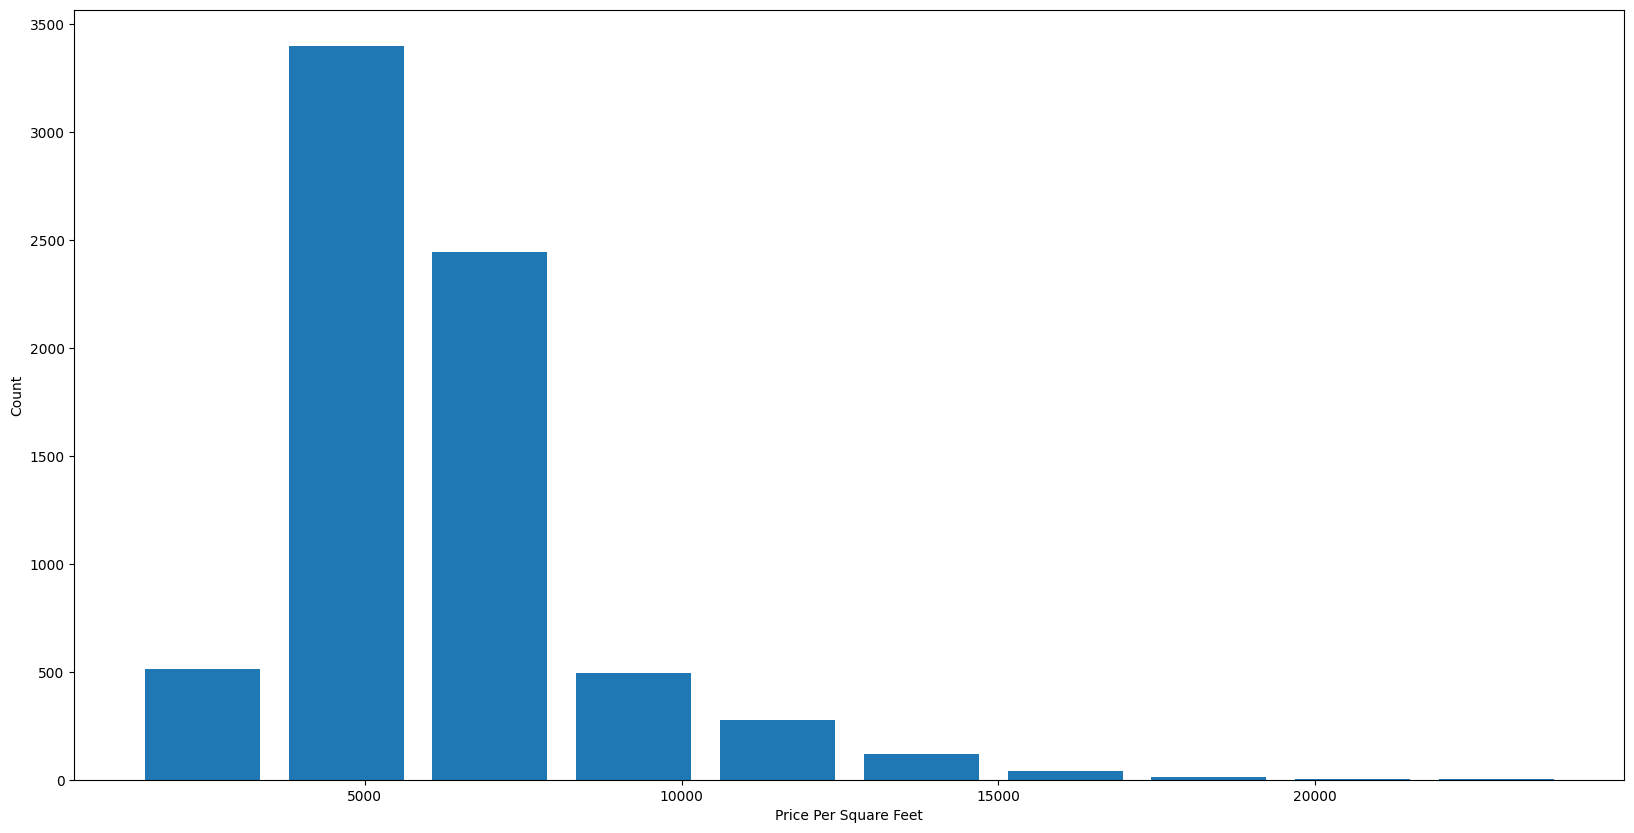

In [79]:
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)
plt.hist(df7.price_per_sqft,rwidth=0.8)
plt.xlabel("Price Per Square Feet")
plt.ylabel("Count")

In [80]:
df8 = df7.copy()

In [81]:
df8.isnull().sum()

area_type            0
availability         0
location             0
size                 0
society           2505
total_sqft           0
bath                 0
balcony            254
price                0
bhk                  0
price_per_sqft       0
sqft_per_bhk         0
dtype: int64

In [82]:
df8["bath"].describe()

count    7300.000000
mean        2.448904
std         1.009609
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max        16.000000
Name: bath, dtype: float64

In [83]:
df8["bath"].value_counts().sort_index()

bath
1.0      578
2.0     4158
3.0     1773
4.0      502
5.0      172
6.0       78
7.0       16
8.0       11
9.0        7
12.0       3
13.0       1
16.0       1
Name: count, dtype: int64

In [84]:
df8[df8["bath"] > df8["bhk"] + 2] #remove

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
1617,Built-up Area,Ready To Move,Chikkabanavar,4 Bedroom,NaN,2460.0,7.0,2.0,80.0,4,3252.032520,615.000000
6688,Super built-up Area,Ready To Move,Thanisandra,3 BHK,Soitya,1806.0,6.0,2.0,116.0,3,6423.034330,602.000000
8402,Super built-up Area,Ready To Move,other,6 BHK,Prowshi,11338.0,9.0,1.0,1000.0,6,8819.897689,1889.666667
9976,Built-up Area,Ready To Move,other,4 Bedroom,NaN,7000.0,8.0,NaN,450.0,4,6428.571429,1750.000000


In [85]:
df8[df8["bath"] == 16]  #possible

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
8578,Super built-up Area,Ready To Move,other,16 BHK,NaN,10000.0,16.0,NaN,550.0,16,5500.0,625.0


In [86]:
df8 = df8[df8["bath"] <= df8["bhk"] + 2]

In [87]:
df8.shape

(7296, 12)

In [88]:
df_clean = df8.copy()

***
***
***

In [89]:
df_clean.isnull().sum()

area_type            0
availability         0
location             0
size                 0
society           2503
total_sqft           0
bath                 0
balcony            253
price                0
bhk                  0
price_per_sqft       0
sqft_per_bhk         0
dtype: int64

***
***

In [90]:
# dropping society
# 2503 missing out of ~7264
# ≈ 34%
df_clean["society"].nunique()

1715

In [91]:
society_stats = df_clean["society"].value_counts()
df_clean["society"].value_counts().head(20)

society
GrrvaGr    66
PrarePa    54
GMown E    53
Prtates    46
Bhmesy     43
Prarkun    43
Sryalan    36
PrityTr    36
Dhalsh     36
SNity S    32
Prityel    31
Prncyrn    27
Prtanha    26
Soresea    26
SNnia E    25
Dieldli    24
SunceEs    23
Soitya     23
DLhtsnd    23
PhestOn    22
Name: count, dtype: int64

In [92]:
society_stats

society
GrrvaGr    66
PrarePa    54
GMown E    53
Prtates    46
Bhmesy     43
           ..
Frowsru     1
MCngeha     1
RohtsHe     1
Binorn      1
NantsGa     1
Name: count, Length: 1715, dtype: int64

In [93]:
society_stats[society_stats < 5]

society
Undge T    4
SNiew L    4
AreraRe    4
Puceswn    4
IBictnd    4
          ..
Frowsru    1
MCngeha    1
RohtsHe    1
Binorn     1
NantsGa    1
Name: count, Length: 1490, dtype: int64

In [94]:
df_rag = df_clean.copy()

In [95]:
df_clean.drop("society", axis=1, inplace=True)

In [96]:
df_clean

,area_type,availability,location,size,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
1,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,1875.0,3.0,1.0,167.0,3,8906.666667,625.000000
2,Built-up Area,Ready To Move,1st Phase JP Nagar,5 Bedroom,1500.0,5.0,NaN,85.0,5,5666.666667,300.000000
3,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,2065.0,4.0,1.0,210.0,3,10169.491525,688.333333
5,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,2059.0,3.0,2.0,225.0,3,10927.634774,686.333333
6,Super built-up Area,Ready To Move,1st Phase JP Nagar,2 BHK,1394.0,2.0,1.0,100.0,2,7173.601148,697.000000
...,...,...,...,...,...,...,...,...,...,...,...
10329,Carpet Area,19-Jan,other,2 BHK,1200.0,2.0,3.0,70.0,2,5833.333333,600.000000
10330,Super built-up Area,Ready To Move,other,1 BHK,1800.0,1.0,1.0,200.0,1,11111.111111,1800.000000
10334,Super built-up Area,Ready To Move,other,2 BHK,1353.0,2.0,2.0,110.0,2,8130.081301,676.500000
10335,Plot Area,18-Jan,other,1 Bedroom,812.0,1.0,0.0,26.0,1,3201.970443,812.000000


In [97]:
# 1. Fill balcony using BHK-wise median
df_clean["balcony"] = df_clean.groupby("bhk")["balcony"].transform(
    lambda x: x.fillna(x.median())
)



/opt/anaconda3/envs/houseprice_automl/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/anaconda3/envs/houseprice_automl/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [98]:
# 2. Fill leftover balcony NaNs using overall median
df_clean["balcony"] = df_clean["balcony"].fillna(df_clean["balcony"].median())



In [99]:
# 3. Check missing values
df_clean.isnull().sum()

area_type         0
availability      0
location          0
size              0
total_sqft        0
bath              0
balcony           0
price             0
bhk               0
price_per_sqft    0
sqft_per_bhk      0
dtype: int64

In [100]:
df_clean.to_csv("../Data/processed/clean_house_data.csv", index=False)

In [101]:
df_clean.shape

(7296, 11)

In [102]:
df_clean[df_clean["balcony"].isnull()][["bhk", "balcony"]]

,bhk,balcony


In [103]:
df_clean["balcony"] = df_clean.groupby("bhk")["balcony"].transform(
    lambda x: x.fillna(x.median())
)

df_clean["balcony"] = df_clean["balcony"].fillna(df_clean["balcony"].median())

In [104]:
df_clean.isnull().sum()

area_type         0
availability      0
location          0
size              0
total_sqft        0
bath              0
balcony           0
price             0
bhk               0
price_per_sqft    0
sqft_per_bhk      0
dtype: int64

In [105]:
df_clean.to_csv("../Data/processed/clean_house_data.csv", index=False)

In [106]:
df_clean.shape

(7296, 11)